### Task 1: Designing a Heuristic for a Warehouse Robot

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 1. Coordinates of warehouse locations
locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}

# 2. Weighted warehouse graph (directed, as in the figure)
warehouse_graph = {
    "Receiving_Area": {"Storage_A": 2.2, "Storage_B": 4.1},
    "Storage_A": {"Sorting_Area": 2.2},
    "Storage_B": {"Inspection_Area": 5.0, "Sorting_Area": 6.0},
    "Sorting_Area": {"Inspection_Area": 3.2, "Packing_Station": 5.0},
    "Inspection_Area": {"Packing_Station": 2.2},
    "Packing_Station": {}
}

# 3. Euclidean heuristic
def heuristic(current, goal):
    (x1, y1), (x2, y2) = locations[current], locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# 4. Calculate heuristic values
goal = "Packing_Station"

print("Heuristic Values")
print("----------------")
rows = []
for location in locations:
    h = heuristic(location, goal)
    print(f"h({location}) = {h:.2f}")
    rows.append({"Location": location, "Coordinates": locations[location], f"h(n) to {goal}": round(h, 2)})

print()
display(pd.DataFrame(rows).style.hide(axis="index"))

Heuristic Values
----------------
h(Receiving_Area) = 9.22
h(Storage_A) = 7.07
h(Storage_B) = 6.32
h(Sorting_Area) = 5.00
h(Inspection_Area) = 2.24
h(Packing_Station) = 0.00



Location,Coordinates,h(n) to Packing_Station
Receiving_Area,"(0, 0)",9.220000
Storage_A,"(2, 1)",7.070000
Storage_B,"(1, 4)",6.320000
Sorting_Area,"(4, 2)",5.000000
Inspection_Area,"(5, 5)",2.240000
Packing_Station,"(7, 6)",0.000000


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, the actual minimum-cost path is highlighted merely for visualization:

In [2]:
# 5. Create NetworkX graph
G = nx.DiGraph()
for node, neighbors in warehouse_graph.items():
    G.add_node(node)
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 6. Find minimum-cost path (weighted shortest path, used only for visualization)
solution_path = nx.shortest_path(G, source="Receiving_Area", target="Packing_Station", weight="weight")
solution_cost = nx.shortest_path_length(G, source="Receiving_Area", target="Packing_Station", weight="weight")

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


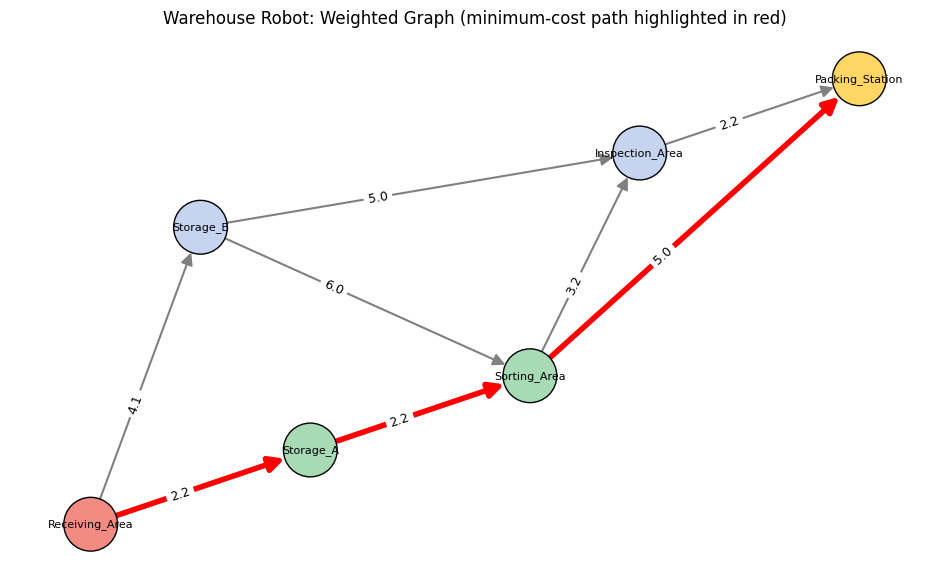

In [3]:
def draw_graph(graph, pos, path=None, title="", start=None, goal=None, ax=None):
    """Draw a weighted directed graph with NetworkX; the solution path is highlighted in red."""
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        G.add_node(node)
        for nb, w in neighbors.items():
            G.add_edge(node, nb, weight=w)
    path_edges = list(zip(path, path[1:])) if path else []
    other_edges = [e for e in G.edges() if e not in path_edges]
    colors = []
    for n in G.nodes():
        if n == start: colors.append("#f28b82")      # start = red-ish
        elif n == goal: colors.append("#fdd663")     # goal = yellow
        elif path and n in path: colors.append("#a8dab5")
        else: colors.append("#c6d4f0")
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1500, edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=other_edges, arrows=True, arrowsize=18,
                           edge_color="gray", width=1.5, node_size=1500, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, arrows=True, arrowsize=22,
                           edge_color="red", width=4, node_size=1500, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"),
                                 font_size=9, label_pos=0.4, ax=ax)

# 7. Visualize graph
pos = locations
plt.figure(figsize=(12, 7))
draw_graph(warehouse_graph, pos, path=solution_path, start="Receiving_Area", goal="Packing_Station")
plt.title("Warehouse Robot: Weighted Graph (minimum-cost path highlighted in red)")
plt.axis("off")
plt.show()

In [4]:
# 8. Verify heuristic condition: h(n) <= cost(n,m) + h(m)
print("\nHeuristic Condition Verification")
print("***********************************")

all_ok = True
for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        h_n = heuristic(node, goal)
        rhs = cost + heuristic(neighbor, goal)
        ok = h_n <= rhs
        all_ok &= ok
        print(f"{node:16s} -> {neighbor:16s}: h(n)={h_n:5.2f} <= cost + h(m) = {cost:.1f} + {heuristic(neighbor, goal):.2f} = {rhs:5.2f}  {'OK' if ok else 'VIOLATED'}")

print("\nHeuristic is consistent on all edges:", all_ok)

# Admissibility check: h(n) must not exceed the true minimum cost from n to the goal
print("\nAdmissibility check (h(n) <= true cost to goal)")
for n in warehouse_graph:
    if n == goal: continue
    true_cost = nx.shortest_path_length(G, n, goal, weight="weight")
    print(f"{n:16s} h(n)={heuristic(n, goal):5.3f}  true cost={true_cost:5.2f}  {'OK' if heuristic(n, goal) <= true_cost else 'over-estimates'}")


Heuristic Condition Verification
***********************************
Receiving_Area   -> Storage_A       : h(n)= 9.22 <= cost + h(m) = 2.2 + 7.07 =  9.27  OK
Receiving_Area   -> Storage_B       : h(n)= 9.22 <= cost + h(m) = 4.1 + 6.32 = 10.42  OK
Storage_A        -> Sorting_Area    : h(n)= 7.07 <= cost + h(m) = 2.2 + 5.00 =  7.20  OK
Storage_B        -> Inspection_Area : h(n)= 6.32 <= cost + h(m) = 5.0 + 2.24 =  7.24  OK
Storage_B        -> Sorting_Area    : h(n)= 6.32 <= cost + h(m) = 6.0 + 5.00 = 11.00  OK
Sorting_Area     -> Inspection_Area : h(n)= 5.00 <= cost + h(m) = 3.2 + 2.24 =  5.44  OK
Sorting_Area     -> Packing_Station : h(n)= 5.00 <= cost + h(m) = 5.0 + 0.00 =  5.00  OK
Inspection_Area  -> Packing_Station : h(n)= 2.24 <= cost + h(m) = 2.2 + 0.00 =  2.20  VIOLATED

Heuristic is consistent on all edges: False

Admissibility check (h(n) <= true cost to goal)
Receiving_Area   h(n)=9.220  true cost= 9.40  OK
Storage_A        h(n)=7.071  true cost= 7.20  OK
Storage_B        h(n

**Why Euclidean distance is suitable:** the robot moves between points on a floor plan, and the straight-line distance between two points is the shortest possible distance between them. A route through the warehouse can therefore never be shorter than the straight line to the Packing Station, so h(n) is a realistic *lower-bound* estimate of the remaining cost (admissible in principle). It is also cheap to compute from the stored coordinates and needs no extra data.

**Observation (one line):** h(n) ≤ cost(n,m) + h(m) holds on 7 of the 8 edges; the only violation is Inspection_Area → Packing_Station, where the given edge cost 2.2 is slightly below the true straight-line length 2.236 (a rounding in the lab data), so h(Inspection_Area) = 2.24 over-estimates by just 0.04 and the heuristic is *consistent/admissible up to that rounding*.

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [5]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates
locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph
airport_graph = {
    "Baggage_Area": {"Security": 2.2, "Checkpoint": 4.1},
    "Security": {"Food_Court": 2.2},
    "Checkpoint": {"Terminal_Hall": 5.0},
    "Food_Court": {"Terminal_Hall": 3.2, "Departure_Gate": 6.0},
    "Terminal_Hall": {"Departure_Gate": 3.2},
    "Departure_Gate": {}
}

# 3. Euclidean heuristic
def heuristic(current, goal):
    (x1, y1), (x2, y2) = locations[current], locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# 4. GBFS: f(n) = h(n)
def greedy_best_first_search(start, goal, graph):
    counter = 0                                   # tie-breaker so the heap never compares node names
    frontier = [(heuristic(start, goal), counter, start)]   # priority queue ordered by h(n) only
    came_from = {start: None}
    visited = set()
    expansion_order = []

    while frontier:
        h, _, current = heapq.heappop(frontier)   # node that LOOKS closest to the goal
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            break

        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in came_from:
                came_from[neighbor] = current
                counter += 1
                heapq.heappush(frontier, (heuristic(neighbor, goal), counter, neighbor))
    else:
        return None, float("inf"), expansion_order   # goal unreachable

    # Reconstruct path
    path, node = [], goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    path.reverse()

    # Calculate actual path cost
    total_cost = sum(graph[a][b] for a, b in zip(path, path[1:]))
    return path, total_cost, expansion_order

# 5. Run GBFS
start = "Baggage_Area"
goal = "Departure_Gate"

path, total_cost, expansion_order = greedy_best_first_search(start, goal, airport_graph)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

print("\nHeuristic values h(n) to Departure_Gate:")
for n in locations:
    print(f"  h({n}) = {heuristic(n, goal):.2f}")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30

Heuristic values h(n) to Departure_Gate:
  h(Baggage_Area) = 10.00
  h(Security) = 7.81
  h(Checkpoint) = 7.28
  h(Food_Court) = 5.66
  h(Terminal_Hall) = 3.16
  h(Departure_Gate) = 0.00


#### NetworkX visualization

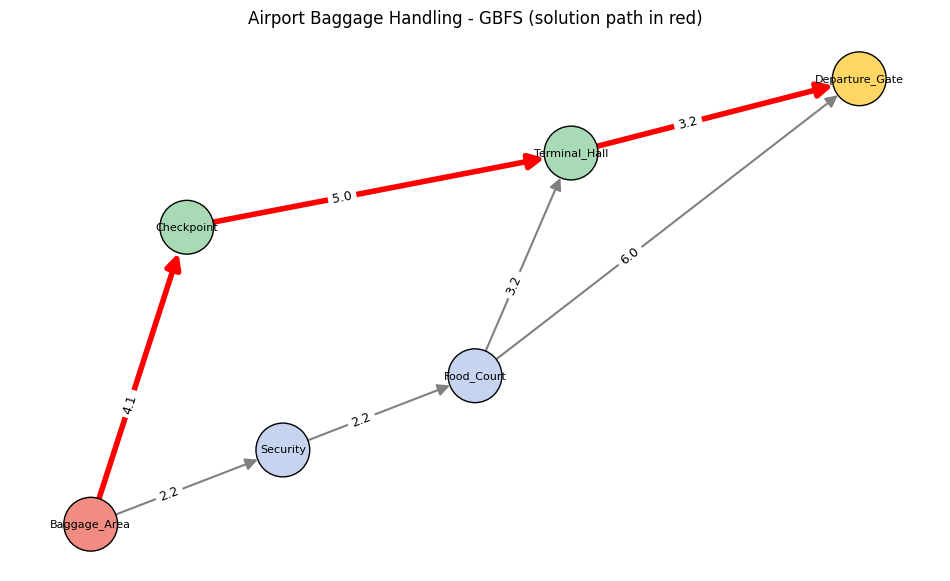

In [6]:
# 6. NetworkX visualization
pos = locations
plt.figure(figsize=(12, 7))
draw_graph(airport_graph, pos, path=path, start=start, goal=goal)
plt.title("Airport Baggage Handling - GBFS (solution path in red)")
plt.axis("off")
plt.show()

**Why GBFS selected the nodes in that order** (f(n) = h(n), the lowest h is expanded first):

1. **Baggage_Area** (h = 10.00) is the start, so it is expanded first. Its neighbours are Security (h = 7.81) and Checkpoint (h = 7.28).
2. **Checkpoint** has the smaller h (7.28 < 7.81), so it looks closer to the gate and is expanded next, even though the edge to it is the more expensive one (4.10 vs 2.20). GBFS ignores g(n).
3. Checkpoint adds **Terminal_Hall** (h = 3.16), which now beats Security (7.81) in the frontier, so it is expanded.
4. Terminal_Hall adds **Departure_Gate** (h = 0), which is picked immediately and the search stops.

Expansion order: Baggage_Area → Checkpoint → Terminal_Hall → Departure_Gate; Security and Food_Court are never expanded.

**Result:** GBFS returns Baggage_Area → Checkpoint → Terminal_Hall → Departure_Gate with **cost 12.30**. This is *not* optimal: the path Baggage_Area → Security → Food_Court → Terminal_Hall → Departure_Gate costs only **10.80**. GBFS is fast because it only follows the heuristic, but it is neither optimal nor cost-aware.

### Task 3: A* Search for Emergency Supply Robot

In [7]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Hospital coordinates
locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}

# 2. Hospital weighted graph
hospital_graph = {
    "Pharmacy": {"Main_Corridor": 2.2, "Patient_Wing": 4.1},
    "Main_Corridor": {"Nursing_Station": 2.2},
    "Patient_Wing": {"Laboratory": 5.0},
    "Nursing_Station": {"Laboratory": 3.2, "Emergency_Ward": 6.0},
    "Laboratory": {"Emergency_Ward": 3.2},
    "Emergency_Ward": {}
}

# 3. Euclidean heuristic
def heuristic(current, goal):
    (x1, y1), (x2, y2) = locations[current], locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# 4. Path reconstruction
def reconstruct_path(came_from, current):
    path = [current]
    while came_from[current] is not None:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

# 5. A* Search: f(n) = g(n) + h(n)
def a_star_search(start, goal, graph):
    counter = 0
    g_cost = {start: 0.0}                         # best known cost from start to each node
    came_from = {start: None}
    frontier = [(heuristic(start, goal), counter, 0.0, start)]   # (f, tie-breaker, g, node)
    expansion_order = []

    while frontier:
        f, _, g, current = heapq.heappop(frontier)
        if g > g_cost[current]:                   # stale entry: a cheaper route was found later
            continue
        expansion_order.append(current)

        if current == goal:
            return reconstruct_path(came_from, current), g, expansion_order, g_cost

        for neighbor, cost in graph[current].items():
            new_g = g_cost[current] + cost
            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                came_from[neighbor] = current
                counter += 1
                heapq.heappush(frontier, (new_g + heuristic(neighbor, goal), counter, new_g, neighbor))

    return None, float("inf"), expansion_order, g_cost

# 6. Run A*
start = "Pharmacy"
goal = "Emergency_Ward"

path, total_cost, expansion_order, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [8]:
print("\nA* Node Information (nodes in expansion order)")
print("*********************")
print(
    f"{'Node':20s}"
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:
    g = g_cost[node]
    h = heuristic(node, goal)
    f = g + h
    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information (nodes in expansion order)
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

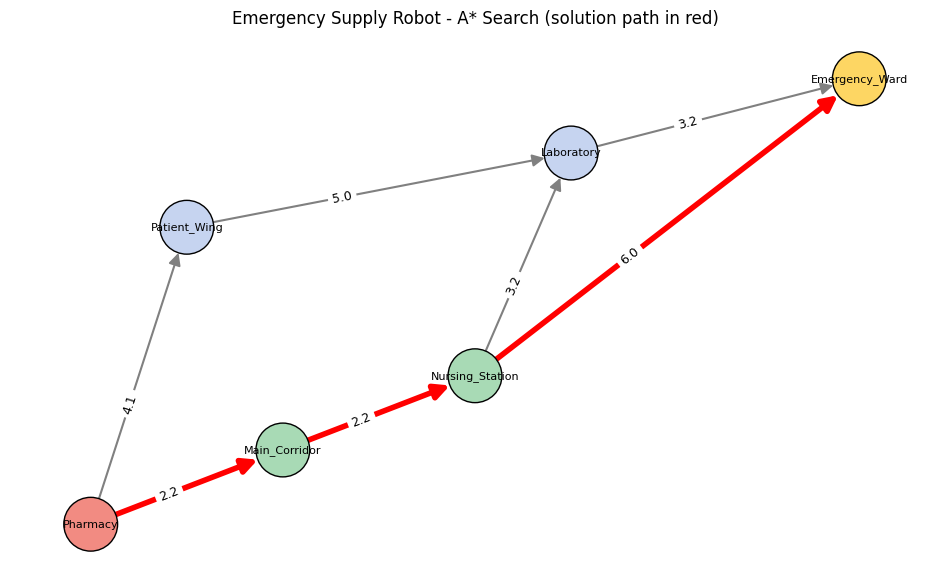

In [9]:
# 7. NetworkX visualization
pos = locations
plt.figure(figsize=(12, 7))
draw_graph(hospital_graph, pos, path=path, start=start, goal=goal)
plt.title("Emergency Supply Robot - A* Search (solution path in red)")
plt.axis("off")
plt.show()

#### Comparison with GBFS on the same hospital graph

In [10]:
# GBFS on the hospital graph (same heuristic, f(n) = h(n)) to compare against A*
def gbfs_hospital(start, goal, graph):
    counter, frontier, came_from, seen, order = 0, [(heuristic(start, goal), 0, start)], {start: None}, set(), []
    while frontier:
        _, _, cur = heapq.heappop(frontier)
        if cur in seen: continue
        seen.add(cur); order.append(cur)
        if cur == goal: break
        for nb in graph[cur]:
            if nb not in seen and nb not in came_from:
                came_from[nb] = cur; counter += 1
                heapq.heappush(frontier, (heuristic(nb, goal), counter, nb))
    p = reconstruct_path(came_from, goal)
    return p, sum(graph[a][b] for a, b in zip(p, p[1:])), order

gp, gc, go = gbfs_hospital(start, goal, hospital_graph)
print(f"{'':10s}{'Expansion order':70s}{'Path cost':>10s}")
print(f"{'GBFS':10s}{' -> '.join(go):70s}{gc:10.2f}   path: {' -> '.join(gp)}")
print(f"{'A*':10s}{' -> '.join(expansion_order):70s}{total_cost:10.2f}   path: {' -> '.join(path)}")

          Expansion order                                                        Path cost
GBFS      Pharmacy -> Patient_Wing -> Laboratory -> Emergency_Ward                   12.30   path: Pharmacy -> Patient_Wing -> Laboratory -> Emergency_Ward
A*        Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward             10.40   path: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward


GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

**Short comparison of A* and GBFS**

- **GBFS (f = h)** only looks at the estimated remaining distance. At the Pharmacy it prefers Patient_Wing (h = 7.28) over Main_Corridor (h = 7.81) and then goes Laboratory → Emergency_Ward, giving a path of cost **12.30**.
- **A\* (f = g + h)** also counts the cost already paid. Patient_Wing has f = 4.10 + 7.28 = 11.38, while Main_Corridor has f = 2.20 + 7.81 = 10.01, so A* goes through Main_Corridor → Nursing_Station and reaches the Emergency Ward with cost **10.40** (optimal).
- Considering g(n) stops the search being lured down an expensive branch just because it points toward the goal; A* pays a few more expansions in some problems but guarantees the optimal path because the Euclidean heuristic is admissible and consistent.

### GUI Requirement: Streamlit App
The Streamlit GUI (`app.py`) imports the **same graph and the same GBFS / A\* functions** from `searchAlgos.py` (the hospital graph from Task 3). It is submitted separately as a GitHub repo + deployed app link, as required by the submission guidelines.

### Task 4: Weighted A* for Autonomous Delivery Drone

In [11]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates
locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph
graph = {
    "Distribution_Center": {"Zone_A": 2.2, "Zone_B": 3.0},
    "Zone_A": {"Zone_C": 2.2},
    "Zone_B": {"Zone_D": 5.0},
    "Zone_C": {"Zone_D": 3.2, "Customer_Building": 6.0},
    "Zone_D": {"Customer_Building": 3.2},
    "Customer_Building": {}
}

# 3. Euclidean Heuristic
def heuristic(node, goal):
    (x1, y1), (x2, y2) = locations[node], locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# 4. Display Heuristic Values
goal = "Customer_Building"

heuristic_data = []
for node in locations:
    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)   (w = 1 gives normal A*)
def weighted_a_star(start, goal, graph, weight):
    counter = 0
    g_cost = {start: 0.0}
    came_from = {start: None}
    frontier = [(weight * heuristic(start, goal), counter, 0.0, start)]   # (f, tie-breaker, g, node)
    expansion_order = []

    while frontier:
        f, _, g, current = heapq.heappop(frontier)
        if g > g_cost[current]:                    # stale entry
            continue
        expansion_order.append(current)

        if current == goal:
            path, node = [], goal
            while node is not None:
                path.append(node)
                node = came_from[node]
            return path[::-1], g, expansion_order

        for neighbor, cost in graph[current].items():
            new_g = g_cost[current] + cost
            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                came_from[neighbor] = current
                counter += 1
                heapq.heappush(frontier, (new_g + weight * heuristic(neighbor, goal), counter, new_g, neighbor))

    return None, float("inf"), expansion_order

# 6. Run Weighted A* for All Required Weights
start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })

# 7. Display Results in dataframe
results_df = pd.DataFrame(results)
print("\nResults Table:")
display(results_df[["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]].style.hide(axis="index"))

# 8. Display Detailed Expansion Orders
print("\nDetailed Expansion Orders:")
for r in results:
    print(f"w = {r['Weight']}: {r['Expansion Order']}")

Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00

Results Table:


Weight,Solution Path,Total Cost,Nodes Expanded
1.000000,Distribution_Center → Zone_A → Zone_C → Customer_Building,10.400000,5
1.500000,Distribution_Center → Zone_A → Zone_C → Customer_Building,10.400000,4
2.000000,Distribution_Center → Zone_B → Zone_D → Customer_Building,11.200000,4
3.000000,Distribution_Center → Zone_B → Zone_D → Customer_Building,11.200000,4



Detailed Expansion Orders:
w = 1: Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building
w = 1.5: Distribution_Center → Zone_A → Zone_C → Customer_Building
w = 2: Distribution_Center → Zone_B → Zone_D → Customer_Building
w = 3: Distribution_Center → Zone_B → Zone_D → Customer_Building


#### NetworkX visualization

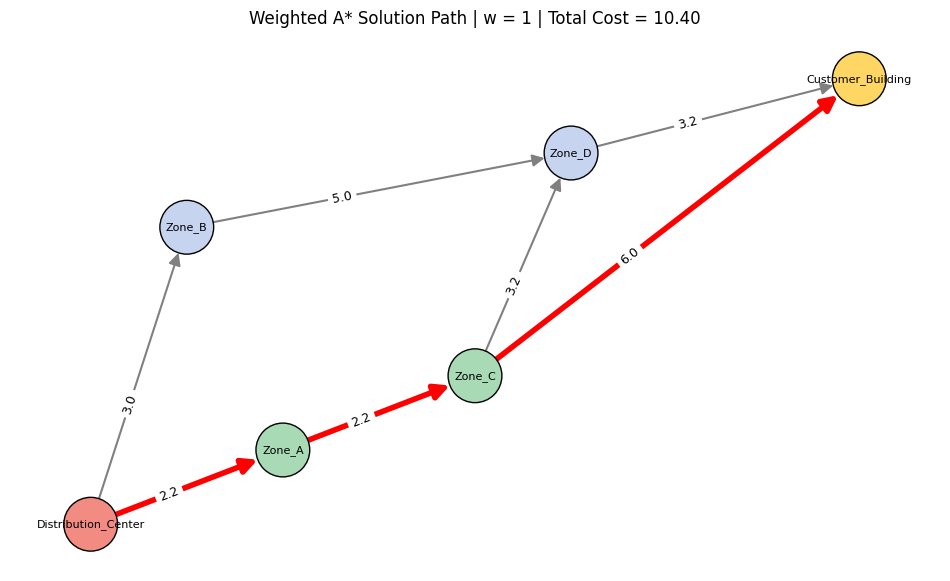

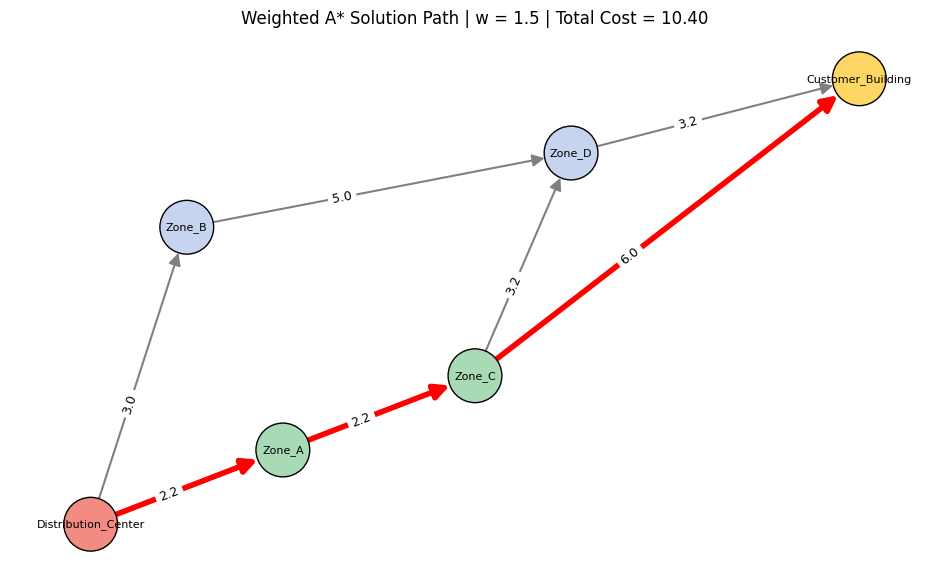

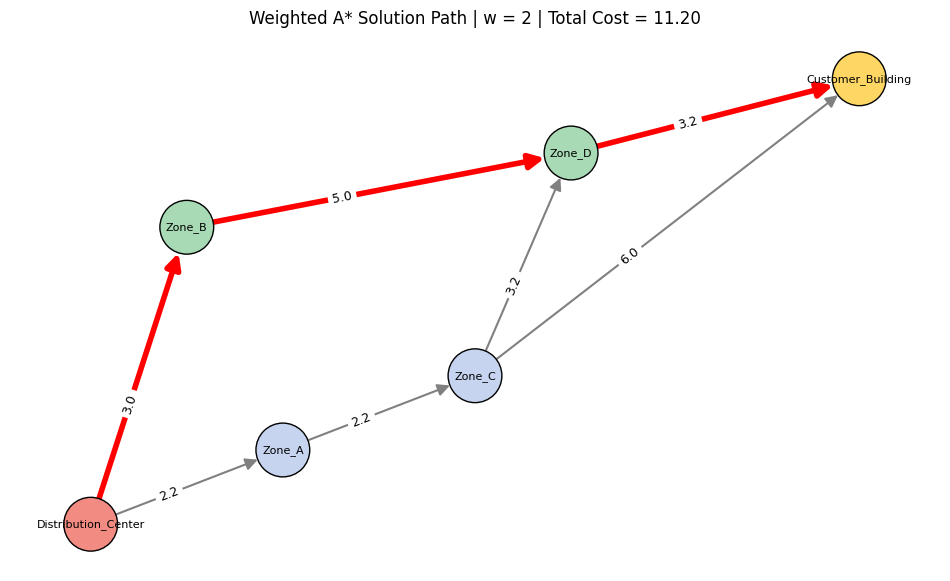

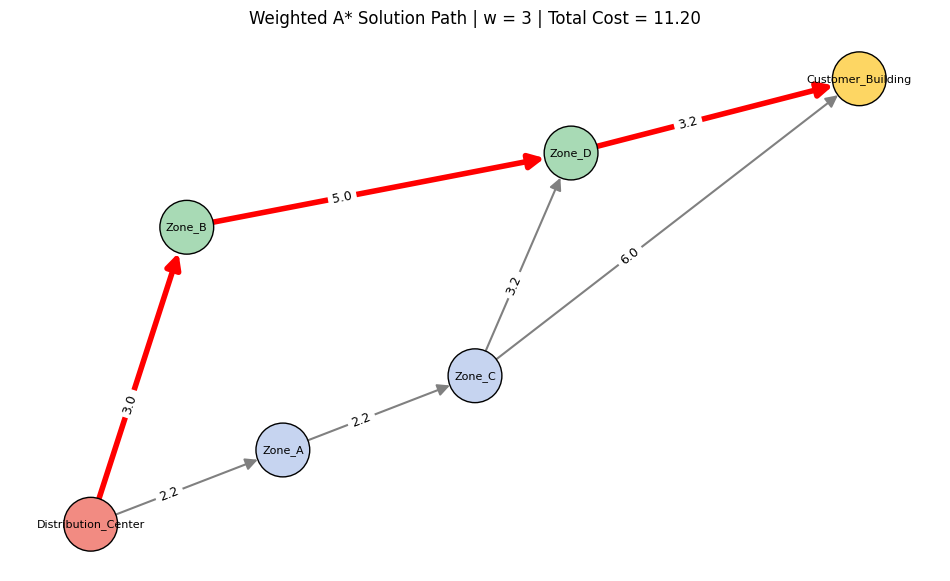

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph
G = nx.DiGraph()

for node, position in locations.items():
    G.add_node(node, pos=position)

for node, neighbors in graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 2. Node Positions
pos = locations

# 3. Visualize Weighted A* Result for Each Weight
for w in weights:
    path, cost, order = weighted_a_star(start, goal, graph, w)

    plt.figure(figsize=(12, 7))
    draw_graph(graph, pos, path=path, start=start, goal=goal)

    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.axis("off")
    plt.show()

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G

#### Results table

| Weight w | Solution Path | Total Cost | Nodes Expanded |
|---|---|---|---|
| 1 | Distribution_Center → Zone_A → Zone_C → Customer_Building | 10.40 | 5 |
| 1.5 | Distribution_Center → Zone_A → Zone_C → Customer_Building | 10.40 | 4 |
| 2 | Distribution_Center → Zone_B → Zone_D → Customer_Building | 11.20 | 4 |
| 3 | Distribution_Center → Zone_B → Zone_D → Customer_Building | 11.20 | 4 |

#### Comparison of results for different w

- **w = 1 (normal A\*)** expands Distribution_Center, Zone_A, Zone_C, **Zone_B**, Customer_Building. Zone_B is expanded (f = 3.0 + 7.28 = 10.28) before the goal because its f is still lower than the goal's f of 10.40. This costs one extra expansion, but the result is the optimal path, **10.40**.
- **w = 1.5** still finds the optimal path, but the heuristic now pulls the search toward the goal harder, so Zone_B (f = 3.0 + 1.5·7.28 = 13.92 vs. Zone_C 12.89) is never expanded: **4 expansions**, same cost 10.40.
- **w = 2 and w = 3** trust the heuristic so much that the search prefers Zone_B (h = 7.28) over Zone_A (h = 7.81), then jumps to Zone_D (h = 3.16). The search is short (**4 expansions**) but the route is more expensive (**11.20**, about 7.7% worse than optimal).
- Beyond w = 2 nothing changes on this small graph, so extra weight gives no further saving here.

#### How increasing w changes the balance between g(n) and h(n)

In f(n) = g(n) + w·h(n), a larger w makes the estimated remaining cost h(n) count more and the cost already travelled g(n) count relatively less. Normal A* (w = 1) *balances* actual cost and estimated cost. Weighted A* *trusts the heuristic more than actual cost*, so it behaves increasingly like GBFS (which is the limit w → ∞, ignoring g). It heads greedily toward nodes that look close to the goal, even when the route to them is already expensive.

#### Why Weighted A* with w > 1 may return a higher-cost path

With w > 1 the function w·h(n) can over-estimate the true remaining cost (it is no longer admissible), so a node on the optimal path may look worse than it really is and get delayed or skipped. Here, going through Zone_B costs only 3.0 so far but has a small h, so it looks very attractive at w = 2, and A* commits to the Zone_B → Zone_D route (11.20) and reaches the goal before the cheaper Zone_A → Zone_C route (10.40) has been fully compared.

#### Does Weighted A* guarantee optimality?

- If w = 1 → Yes (normal A*, with an admissible heuristic).
- If w > 1 → No (may lose optimality; the solution cost is only guaranteed to be at most w times the optimal cost).

Increasing w gives greater importance to the heuristic. This can reduce the amount of search in some problems (here 5 → 4 expansions), but it can also produce a higher-cost solution (here 10.40 → 11.20) because w > 1 does not provide the same optimality guarantee as normal A*.